# Détection de raies par résidu de diffusion — Gabor, Radon, Hough

Ce notebook rejoue, étape par étape, le pipeline déjà implémenté dans
`src/` et `scripts/` pour la dernière étape du challenge (voir
`diffusion_anomaly.pdf`, section 5) : transformer le résidu de purification
d'un patch en une décision `horizontal` / `other`, **sans entraînement
supervisé**.

Démarche :
1. Choisir quelques patches annotés représentatifs de chaque catégorie.
2. Les purifier avec le modèle de diffusion et calculer leur résidu (Eq. 10).
3. Visualiser les trois détecteurs (Radon, Hough, Gabor) eux-mêmes en
   fonction de l'orientation θ, pas seulement leur résultat.
4. Calculer le profil d'orientation R(θ) de chaque détecteur sur le résidu,
   et en déduire un score `horizontal` / `other`.
5. Reprendre les résultats déjà calculés sur les 2863 patches de test
   (`outputs/`, produits par `scripts/annotate_test_set.py`).
6. Évaluer les 3 détecteurs sur les 502 patches annotés
   (`scripts/evaluate_annotated.py`), avec les mises en garde du challenge :
   peu d'exemples, classes déséquilibrées, risque de fuite si les seuils
   sont calés sur les labels.
7. Regarder quelques erreurs pour comprendre les limites.

Aucune fonction n'est redéfinie ici : ce notebook importe `src/purification.py`,
`src/line_detection.py` et `src/metrics.py`.


In [ ]:
import os
import sys
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = os.path.abspath("..")
sys.path.append(os.path.join(ROOT, "src"))

from inference import load_diffusion_model
from purification import residual_maps
from line_detection import ANGLES, DETECTORS, gabor_kernel, scores_from_profile, scores_from_profiles
import line_detection  # pour line_detection._line_coordinates (section 4)
from metrics import roc_auc, average_precision, binary_metrics

DATASET_DIR = os.path.join(ROOT, "dataset")
TEST_DIR = os.path.join(DATASET_DIR, "test")
MODELS_DIR = os.path.join(ROOT, "models")
OUT_DIR = os.path.join(ROOT, "outputs")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] device = {DEVICE}")

with open(os.path.join(DATASET_DIR, "annotations.json")) as f:
    annotations = json.load(f)

n_test = len([f for f in os.listdir(TEST_DIR) if f.endswith(".npy")])
h = np.array([a["horizontal"] for a in annotations.values()], dtype=bool)
o = np.array([a["other"] for a in annotations.values()], dtype=bool)
print(f"Annotated patches      : {len(annotations)} / {n_test}")
print(f"  No line              : {np.sum(~h & ~o)}")
print(f"  Horizontal only      : {np.sum(h & ~o)}")
print(f"  Other only           : {np.sum(~h & o)}")
print(f"  Horizontal and other : {np.sum(h & o)}")


[INFO] device = cpu
Annotated patches      : 502 / 2863
  No line              : 364
  Horizontal only      : 57
  Other only           : 68
  Horizontal and other : 13


## 1. Dix patches illustratifs

Deux ou trois patches annotés par catégorie : `horizontal` seul, `other`
seul, les deux à la fois, et aucune raie. `patch_9107_22` et `patch_9150_13`
sont les mêmes exemples que `scripts/detect_lines_demo.py`.


In [ ]:
EXAMPLE_PATCHES = {
    "horizontal": ["patch_9107_22.npy", "patch_9448_21.npy", "patch_9873_21.npy"],
    "other":      ["patch_9150_13.npy", "patch_9241_11.npy", "patch_9643_21.npy"],
    "both":       ["patch_9351_13.npy", "patch_9350_10.npy"],
    "none":       ["patch_978_21.npy", "patch_981_21.npy"],
}


def load_patch(name: str) -> np.ndarray:
    """Load a raw patch and standardize it (zero mean, unit variance)."""
    patch = np.load(os.path.join(TEST_DIR, name)).astype(np.float32).squeeze()
    return (patch - patch.mean()) / (patch.std() + 1e-8)


rows = []
for category, names in EXAMPLE_PATCHES.items():
    for name in names:
        a = annotations[name]
        rows.append({"category": category, "file": name, **a})
examples_df = pd.DataFrame(rows)
examples_df


,category,file,horizontal,other
0,horizontal,patch_9107_22.npy,True,False
1,horizontal,patch_9448_21.npy,True,False
2,horizontal,patch_9873_21.npy,True,False
3,other,patch_9150_13.npy,False,True
4,other,patch_9241_11.npy,False,True
5,other,patch_9643_21.npy,False,True
6,both,patch_9351_13.npy,True,True
7,both,patch_9350_10.npy,True,True
8,none,patch_978_21.npy,False,False
9,none,patch_981_21.npy,False,False


## 2. Purification et résidu (Eq. 10)

On bruite chaque patch jusqu'à `t_start`, puis on le reconstruit par DDIM
avec le modèle `unet32` (réglages rapides). Le résidu est
`e = |x0 - x0_hat| / (1 + |x0_hat|)` : calculé par `residual_maps`, il vaut
0 là où la reconstruction est parfaite, et croît là où le modèle — entraîné
uniquement sur du bruit — ne parvient pas à reconstruire une structure.


In [ ]:
MODEL = "unet32"
T_START = 600
DDIM_STEPS = 6
SEED = 0

model, schedule = load_diffusion_model(os.path.join(MODELS_DIR, f"{MODEL}.pt"), DEVICE)

names = [n for names in EXAMPLE_PATCHES.values() for n in names]
patches = np.stack([load_patch(n) for n in names])
residuals = residual_maps(patches, model, schedule, T_START, DDIM_STEPS, SEED, DEVICE)
print(f"[INFO] residuals: {residuals.shape}")


[INFO] residuals: (10, 48, 48)


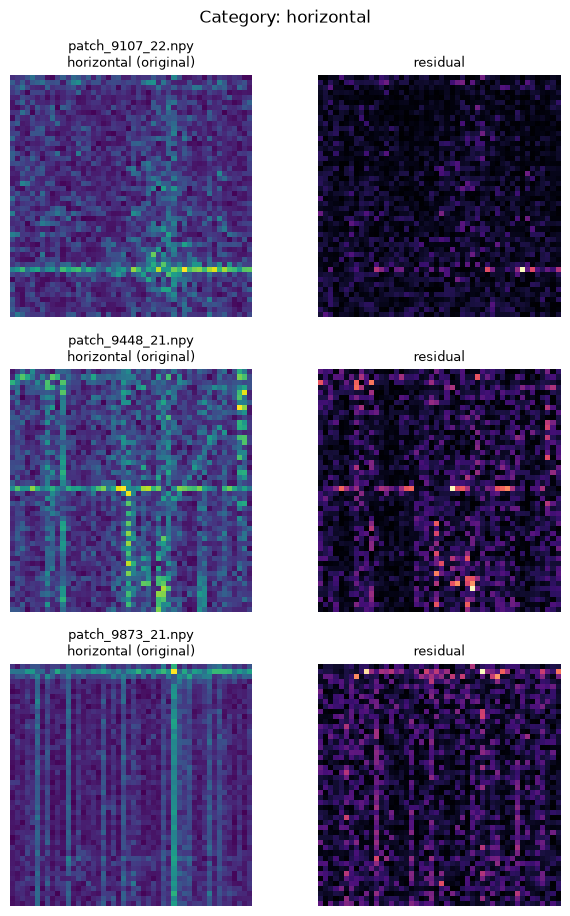

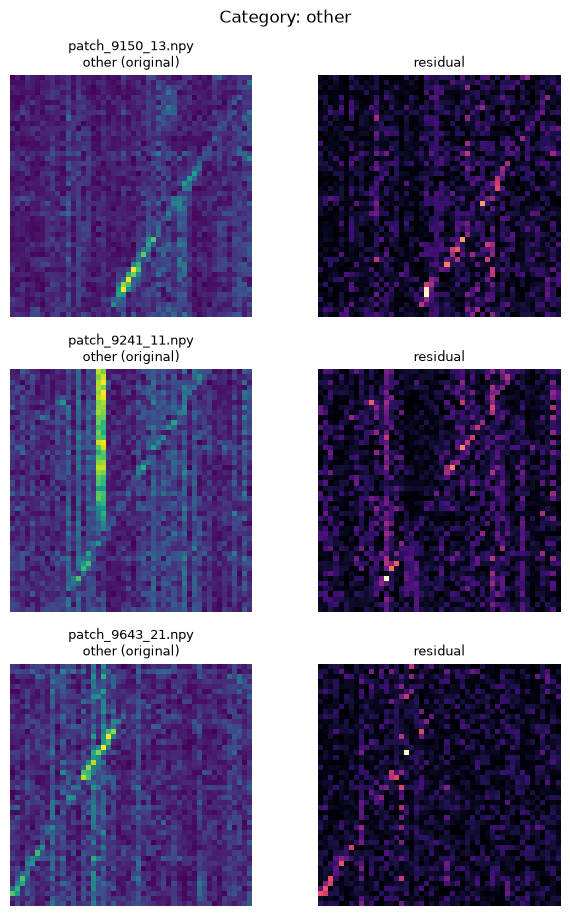

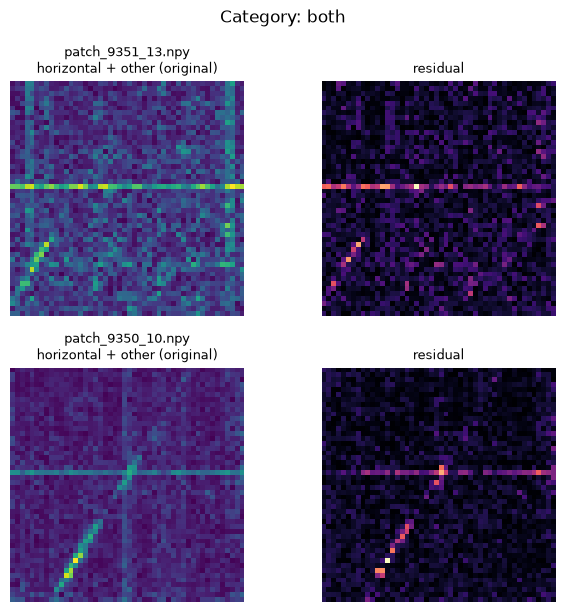

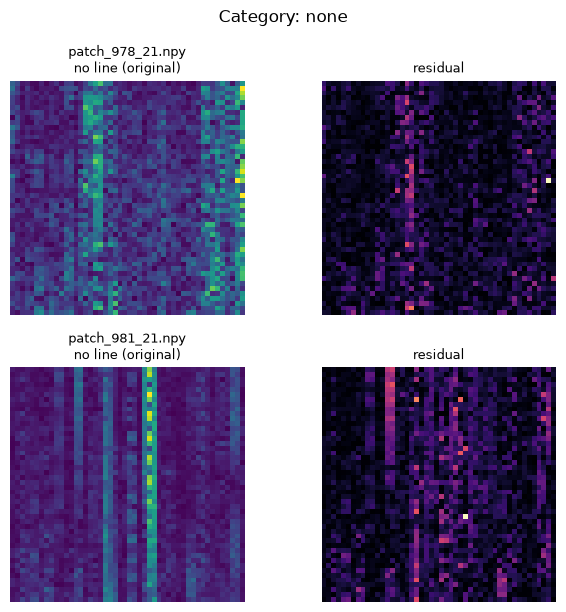

In [ ]:
def show_originals_and_residuals(category: str) -> None:
    """Grid: original patch (left) vs residual (right), one row per patch."""
    cat_names = EXAMPLE_PATCHES[category]
    idx = [names.index(n) for n in cat_names]
    fig, axes = plt.subplots(len(idx), 2, figsize=(6.5, 3.1 * len(idx)), squeeze=False)
    for row, i in enumerate(idx):
        a = annotations[names[i]]
        labels = [k for k in ("horizontal", "other") if a[k]] or ["no line"]
        axes[row, 0].imshow(patches[i], origin="lower")
        axes[row, 0].set_title(f"{names[i]}\n{' + '.join(labels)} (original)", fontsize=9)
        axes[row, 1].imshow(residuals[i], origin="lower", cmap="magma")
        axes[row, 1].set_title("residual", fontsize=9)
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(f"Category: {category}")
    plt.tight_layout()
    plt.show()


for category in EXAMPLE_PATCHES:
    show_originals_and_residuals(category)


## 3. À quoi ressemblent les filtres, en fonction de θ

Avant de regarder leur résultat, on regarde les détecteurs eux-mêmes.

### Gabor
Un noyau `gabor_kernel(theta)` est une gaussienne allongée le long de
l'orientation θ, modulée par un cosinus perpendiculaire à cette direction :
il répond fort à une ligne brillante orientée à θ, et reste ~nul sur un
fond plat (le noyau est centré : moyenne nulle).

### Radon / Hough
Ces deux détecteurs somment (Radon) ou votent (Hough) le long de droites
parallèles à θ. La fonction interne `line_detection._line_coordinates`
donne, pour un θ donné, la distance signée ρ de chaque pixel à la droite
passant par le centre : deux pixels sur la même droite ont le même ρ. Les
lignes de niveau de cette carte *sont* les droites sommées par le
détecteur.


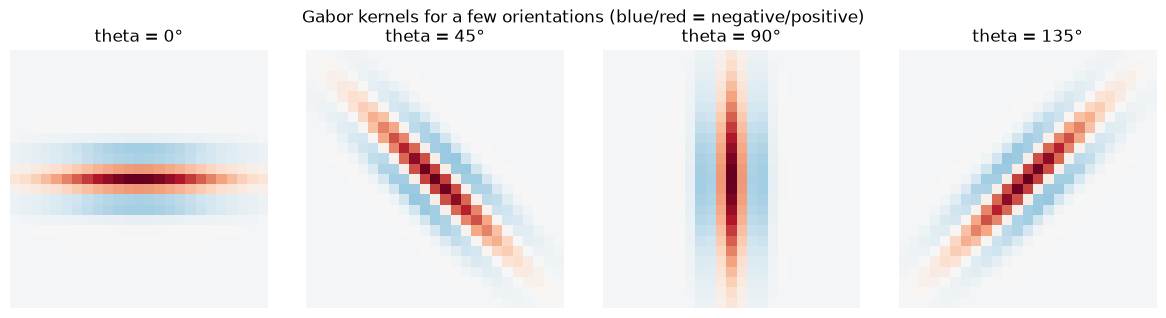

In [ ]:
THETA_DEMO = [0, 45, 90, 135]

fig, axes = plt.subplots(1, len(THETA_DEMO), figsize=(3.0 * len(THETA_DEMO), 3.2))
for ax, theta in zip(axes, THETA_DEMO):
    k = gabor_kernel(theta)
    vmax = np.abs(k).max()
    im = ax.imshow(k, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"theta = {theta}°")
    ax.axis("off")
fig.suptitle("Gabor kernels for a few orientations (blue/red = negative/positive)")
plt.tight_layout()
plt.show()


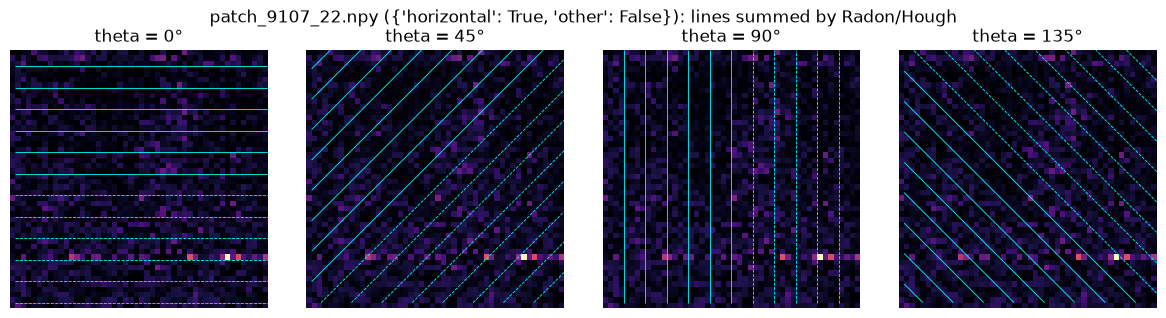

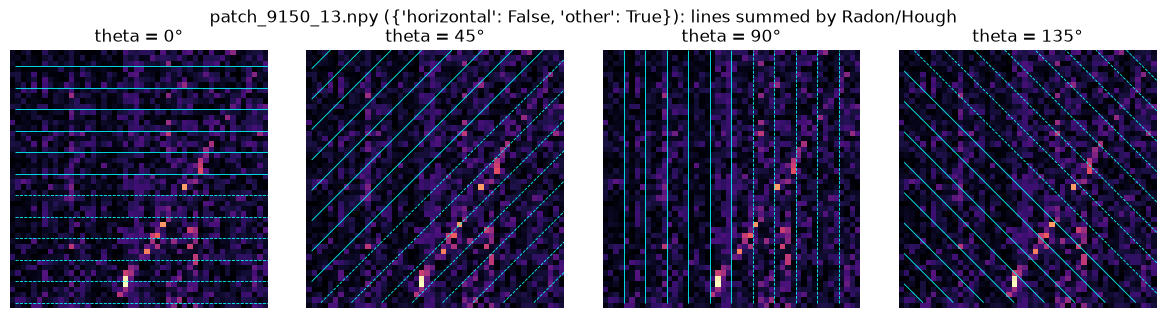

In [ ]:
def show_line_geometry(patch_name: str) -> None:
    """Residual with, for a few theta, the iso-distance lines summed by
    the Radon/Hough detectors overlaid as contours."""
    i = names.index(patch_name)
    e = residuals[i]
    fig, axes = plt.subplots(1, len(THETA_DEMO), figsize=(3.0 * len(THETA_DEMO), 3.2))
    for ax, theta in zip(axes, THETA_DEMO):
        rho = line_detection._line_coordinates(e.shape, theta)
        ax.imshow(e, origin="lower", cmap="magma")
        levels = np.arange(rho.min(), rho.max(), 4.0)  # one line every ~4 px
        ax.contour(rho, levels=levels, colors="cyan", linewidths=0.6, origin="lower")
        ax.set_title(f"theta = {theta}°")
        ax.axis("off")
    fig.suptitle(f"{patch_name} ({annotations[patch_name]}): lines summed by Radon/Hough")
    plt.tight_layout()
    plt.show()


show_line_geometry("patch_9107_22.npy")  # horizontal
show_line_geometry("patch_9150_13.npy")  # other (oblique)


## 4. Profils d'orientation R(θ) et scores

Pour chaque patch, chaque détecteur donne une valeur d'évidence par
orientation. `scores_from_profile` en tire deux scores : le max du profil
près de θ=0/180 (`horizontal`), et le max du profil sur les autres
orientations en excluant la bande verticale (`other`) — les structures
verticales ne sont pas annotées (voir le PDF, section 4).


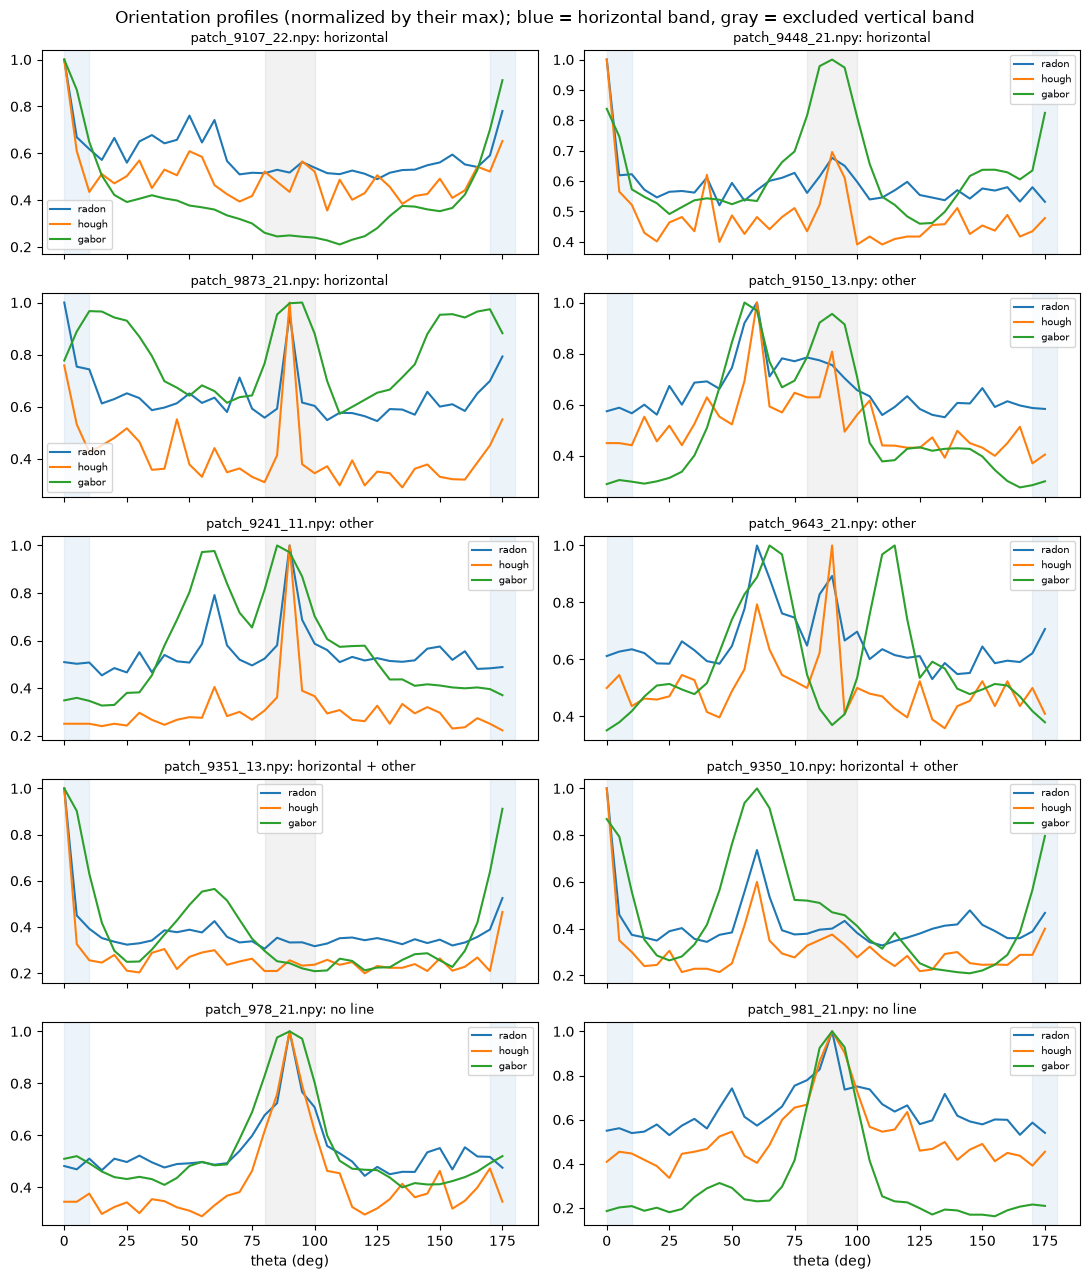

,file,detector,score_horizontal,score_other,horizontal,other
0,patch_9107_22.npy,radon,1.271,0.967,True,False
1,patch_9107_22.npy,hough,0.479,0.292,True,False
2,patch_9107_22.npy,gabor,0.490,0.260,True,False
3,patch_9448_21.npy,radon,1.254,0.786,True,False
4,patch_9448_21.npy,hough,0.479,0.297,True,False
5,patch_9448_21.npy,gabor,0.274,0.228,True,False
6,patch_9873_21.npy,radon,1.050,0.747,True,False
7,patch_9873_21.npy,hough,0.458,0.333,True,False
8,patch_9873_21.npy,gabor,0.169,0.167,True,False
9,patch_9150_13.npy,radon,0.604,1.028,False,True


In [ ]:
H_TOL, V_TOL = 10.0, 10.0  # mêmes tolérances que le run calibré dans outputs/

fig, axes = plt.subplots(5, 2, figsize=(11, 13), sharex=True)
score_rows = []
for ax, i in zip(axes.flat, range(len(names))):
    name = names[i]
    a = annotations[name]
    true_labels = [k for k in ("horizontal", "other") if a[k]] or ["no line"]
    for det_name, detector in DETECTORS.items():
        prof = detector(residuals[i])
        s_h, s_o = scores_from_profile(prof, h_tol=H_TOL, v_tol=V_TOL)
        score_rows.append({
            "file": name, "detector": det_name,
            "score_horizontal": s_h, "score_other": s_o,
            **a,
        })
        ax.plot(ANGLES, prof / prof.max(), label=det_name)
    ax.axvspan(0, H_TOL, color="tab:blue", alpha=0.08)
    ax.axvspan(180 - H_TOL, 180, color="tab:blue", alpha=0.08)
    ax.axvspan(90 - V_TOL, 90 + V_TOL, color="gray", alpha=0.10)
    ax.set_title(f"{name}: {' + '.join(true_labels)}", fontsize=9)
    ax.legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("theta (deg)")
fig.suptitle("Orientation profiles (normalized by their max); "
             "blue = horizontal band, gray = excluded vertical band")
plt.tight_layout()
plt.show()

scores_df = pd.DataFrame(score_rows)
scores_df.round(3)


## 5. Passage à l'échelle : résultats déjà calculés sur les 2863 patches

Calculer le résidu des 2863 patches de test prend du temps : c'est déjà
fait par `scripts/annotate_test_set.py` et mis en cache dans `outputs/`.
On relit ces résultats plutôt que de les recalculer ici.

`annotate_test_set.py` calibre un seuil par détecteur et par label
**uniquement sur les patches non annotés** (quantile 1-ALPHA de leurs
scores, ALPHA = taux de fausse alarme toléré) : les 502 annotations ne
servent qu'à évaluer, jamais à choisir ce seuil.


In [ ]:
LABELS = ("horizontal", "other")
run_config_path = os.path.join(OUT_DIR, "run_config.json")

if not os.path.exists(run_config_path):
    print(
        "[ATTENTION] outputs/run_config.json est introuvable.\n"
        "Lancez d'abord, depuis la racine du projet :\n"
        "    python scripts/annotate_test_set.py\n"
        "puis ré-exécutez cette cellule."
    )
else:
    with open(run_config_path) as f:
        cfg = json.load(f)
    data = np.load(os.path.join(OUT_DIR, "profiles.npz"))
    files = [str(f) for f in data["files"]]
    print(
        f"=== {cfg['model']}, t_start={cfg['t_start']}, K={cfg['ddim_steps']}, "
        f"seed={cfg['seed']}, H_TOL={cfg['h_tol']}, V_TOL={cfg['v_tol']}, "
        f"ALPHA={cfg['alpha']} ==="
    )
    thresholds_df = pd.DataFrame(cfg["thresholds"], index=list(LABELS)).T
    thresholds_df.columns = [f"threshold_{lab}" for lab in LABELS]

    flagged_rows = []
    for name in DETECTORS:
        with open(os.path.join(OUT_DIR, f"predictions_{name}.json")) as f:
            preds = json.load(f)
        flagged_rows.append({
            "detector": name,
            **{f"flagged_{lab}_pct": 100 * np.mean([p[lab] for p in preds.values()]) for lab in LABELS},
        })
    flagged_df = pd.DataFrame(flagged_rows).set_index("detector")
    display(thresholds_df.round(3))
    display(flagged_df.round(2))


=== unet32, t_start=600, K=6, seed=0, H_TOL=10.0, V_TOL=10.0, ALPHA=0.1 ===


,threshold_horizontal,threshold_other
radon,1.447,1.065
hough,0.604,0.440
gabor,0.404,0.439


,flagged_horizontal_pct,flagged_other_pct
detector,,
radon,9.75,10.02
hough,9.68,9.01
gabor,9.81,9.81


## 6. Métriques sur les 502 patches annotés

AUC et average precision ne dépendent d'aucun seuil ; accuracy / precision /
recall / F1 utilisent les seuils calibrés ci-dessus (jamais réglés sur ces
502 patches). Rappel du PDF : les classes sont déséquilibrées (≈73% de
patches sans raie), et évaluer avec seulement 502 exemples annotés rend
toute conclusion fragile — ces chiffres sont indicatifs, pas définitifs.


In [ ]:
if os.path.exists(run_config_path):
    idx = np.array([i for i, f in enumerate(files) if f in annotations])
    Y = {
        lab: np.array([annotations[files[i]][lab] for i in idx], dtype=bool)
        for lab in LABELS
    }
    print(
        f"[INFO] {len(idx)} annotated patches "
        f"(horizontal: {Y['horizontal'].sum()}, other: {Y['other'].sum()})"
    )

    detail_rows, macro_f1 = [], {}
    for name in DETECTORS:
        profiles = data[f"profile_{name}"][idx]
        scores = scores_from_profiles(profiles, h_tol=cfg["h_tol"], v_tol=cfg["v_tol"])
        pred = scores > np.array(cfg["thresholds"][name])
        f1s = []
        for j, lab in enumerate(LABELS):
            y, s = Y[lab], scores[:, j]
            m = binary_metrics(y, pred[:, j])
            f1s.append(m["f1"])
            detail_rows.append({
                "detector": name, "label": lab,
                "AUC": roc_auc(y, s), "AP": average_precision(y, s), **m,
            })
        macro_f1[name] = float(np.mean(f1s))

    results_df = pd.DataFrame(detail_rows).set_index(["detector", "label"])
    display(results_df.round(3))

    exact_rows = []
    for name in DETECTORS:
        profiles = data[f"profile_{name}"][idx]
        scores = scores_from_profiles(profiles, h_tol=cfg["h_tol"], v_tol=cfg["v_tol"])
        pred = scores > np.array(cfg["thresholds"][name])
        exact = (pred == np.stack([Y[l] for l in LABELS], axis=1)).all(axis=1).mean()
        exact_rows.append({"detector": name, "macro_f1": macro_f1[name], "exact_match": exact})
    summary_df = pd.DataFrame(exact_rows).set_index("detector")

    baseline = {lab: 1 - Y[lab].mean() for lab in LABELS}
    baseline["exact_match"] = 1 - (Y["horizontal"] | Y["other"]).mean()
    print(f"baseline 'never a line' (accuracy): {baseline}")
    display(summary_df.round(3))


[INFO] 502 annotated patches (horizontal: 70, other: 81)


AUC     AP  accuracy  precision  recall     f1  fp  fn
detector label                                                               
radon    horizontal  0.941  0.891     0.946      1.000   0.614  0.761   0  27
         other       0.799  0.627     0.888      0.745   0.469  0.576  13  43
hough    horizontal  0.953  0.924     0.954      1.000   0.671  0.803   0  23
         other       0.812  0.574     0.875      0.737   0.346  0.471  10  53
gabor    horizontal  0.933  0.820     0.934      0.911   0.586  0.713   4  29
         other       0.882  0.675     0.884      0.756   0.420  0.540  11  47

baseline 'never a line' (accuracy): {'horizontal': np.float64(0.8605577689243028), 'other': np.float64(0.8386454183266933), 'exact_match': np.float64(0.7250996015936255)}


,macro_f1,exact_match
detector,,
radon,0.668,0.845
hough,0.637,0.839
gabor,0.626,0.829


In [ ]:
if os.path.exists(run_config_path):
    TOL_SWEEP = (5.0, 10.0, 15.0, 20.0, 30.0)
    sweep_rows = []
    for name in DETECTORS:
        profiles = data[f"profile_{name}"][idx]
        for tol in TOL_SWEEP:
            scores = scores_from_profiles(profiles, h_tol=tol, v_tol=cfg["v_tol"])
            row = {"detector": name, "h_tol": tol}
            for j, lab in enumerate(LABELS):
                row[f"AUC_{lab}"] = roc_auc(Y[lab], scores[:, j])
            sweep_rows.append(row)
    sweep_df = pd.DataFrame(sweep_rows).set_index(["detector", "h_tol"])
    print(
        "Sensibilité de l'AUC à la tolérance angulaire H_TOL "
        "(analyse de sensibilité seulement : ne pas choisir H_TOL ici, "
        "ce serait régler la méthode sur les labels)."
    )
    display(sweep_df.round(3))


Sensibilité de l'AUC à la tolérance angulaire H_TOL (analyse de sensibilité seulement : ne pas choisir H_TOL ici, ce serait régler la méthode sur les labels).


AUC_horizontal  AUC_other
detector h_tol                           
radon    5.0             0.946      0.791
         10.0            0.941      0.799
         15.0            0.936      0.801
         20.0            0.932      0.806
         30.0            0.943      0.818
hough    5.0             0.953      0.807
         10.0            0.953      0.812
         15.0            0.947      0.817
         20.0            0.943      0.824
         30.0            0.943      0.835
gabor    5.0             0.937      0.865
         10.0            0.933      0.882
         15.0            0.929      0.894
         20.0            0.924      0.901
         30.0            0.928      0.907

## 7. Quelques erreurs, pour voir ce qui rate

Pour le détecteur au meilleur macro-F1 moyen, on regarde quelques faux
positifs et faux négatifs par label. Le résidu de chaque patch est relu
depuis le cache `outputs/residuals_*.npy` (même run, donc même ordre de
fichiers que `profiles.npz`) plutôt que recalculé.


[INFO] meilleur détecteur (macro-F1 moyen): radon (0.668)


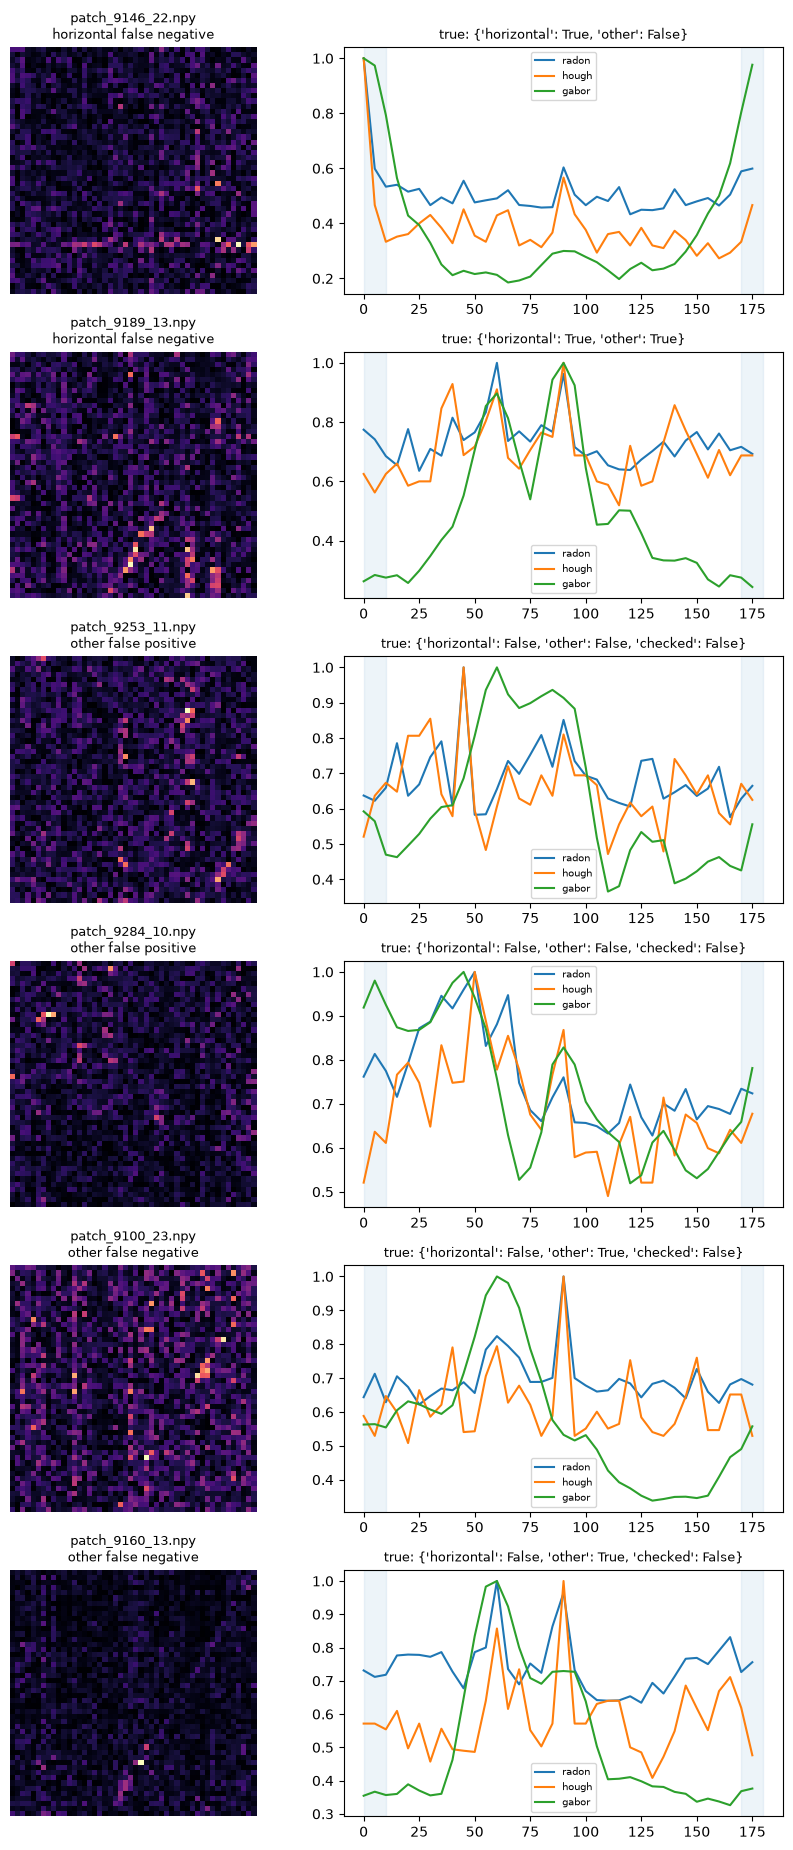

In [ ]:
if os.path.exists(run_config_path):
    best = max(macro_f1, key=macro_f1.get)
    print(f"[INFO] meilleur détecteur (macro-F1 moyen): {best} ({macro_f1[best]:.3f})")

    residuals_cache = os.path.join(
        OUT_DIR, f"residuals_{cfg['model']}_t{cfg['t_start']}_k{cfg['ddim_steps']}_s{cfg['seed']}.npy"
    )
    all_residuals = np.load(residuals_cache, mmap_mode="r")

    profiles_best = data[f"profile_{best}"][idx]
    scores_best = scores_from_profiles(profiles_best, h_tol=cfg["h_tol"], v_tol=cfg["v_tol"])
    pred_best = scores_best > np.array(cfg["thresholds"][best])

    examples = []
    for j, lab in enumerate(LABELS):
        y = Y[lab]
        fp = idx[(~y) & pred_best[:, j]][:2]
        fn = idx[y & ~pred_best[:, j]][:2]
        examples += [(i, lab, "false positive") for i in fp]
        examples += [(i, lab, "false negative") for i in fn]

    if not examples:
        print("[INFO] Aucune erreur trouvée pour ce détecteur et ces seuils.")
    else:
        fig, axes = plt.subplots(len(examples), 2, figsize=(9, 3.1 * len(examples)), squeeze=False)
        for row, (i, lab, kind) in enumerate(examples):
            fname = files[i]
            e = all_residuals[i]
            axes[row, 0].imshow(e, origin="lower", cmap="magma")
            axes[row, 0].set_title(f"{fname}\n{lab} {kind}", fontsize=9)
            axes[row, 0].axis("off")
            for det_name, detector in DETECTORS.items():
                prof = data[f"profile_{det_name}"][i]
                axes[row, 1].plot(ANGLES, prof / prof.max(), label=det_name)
            axes[row, 1].axvspan(0, cfg["h_tol"], color="tab:blue", alpha=0.08)
            axes[row, 1].axvspan(180 - cfg["h_tol"], 180, color="tab:blue", alpha=0.08)
            axes[row, 1].set_title(f"true: {annotations[fname]}", fontsize=9)
            axes[row, 1].legend(fontsize=7)
        plt.tight_layout()
        plt.show()


## 8. Conclusion

- Les trois détecteurs (Radon, Hough, Gabor) exploitent la même idée —
  chercher, dans le résidu, l'orientation qui concentre le plus d'évidence
  — avec des mécanismes différents : moyenne le long des droites (Radon),
  vote binaire (Hough), filtrage adapté (Gabor).
- Les scores et métriques ci-dessus se recalculent à volonté : `T_START`,
  `DDIM_STEPS`, le modèle (`unet32`/`unet64`), la graine, et les tolérances
  `H_TOL`/`V_TOL` sont tous des choix qui changent le résultat (voir
  `scripts/annotate_test_set.py`).
- Limites de cette évaluation, à garder en tête (PDF, section 5) :
  seulement 502 patches annotés, classes très déséquilibrées (364 sans
  raie / 57 horizontal / 68 other / 13 les deux), et les seuils sont
  calibrés sur les patches **non annotés** pour éviter la fuite — mais le
  choix de `H_TOL`/`V_TOL` et des paramètres de purification, eux, restent
  affinés à l'œil sur des exemples annotés, donc l'évaluation finale reste
  optimiste.
- Pistes non explorées ici : moyenner le résidu sur plusieurs graines ou
  valeurs de `t_start`, agréger l'évidence sur des patches adjacents dans
  le temps (une raie peut continuer d'un patch à l'autre), et un traitement
  spécifique pour les lignes obliques, signalées comme plus difficiles à
  détecter dans le PDF.
